# Isolation Forest — Hyperparameter Comparison

This notebook follows the same workflow as `isolation_forest.ipynb` but runs the model across **6 hyperparameter configurations** to compare their performance.

**Configurations tested:**

| # | n_estimators | max_samples | max_features | Rationale |
|---|---|---|---|---|
| 1 | 50 | auto | 1.0 | Few trees, all features — fast but unstable scores |
| 2 | 100 | auto | 1.0 | Default settings — baseline |
| 3 | 200 | auto | 1.0 | Many trees, all features — more stable scores |
| 4 | 100 | auto | 0.5 | Default trees, half the features — adds randomness |
| 5 | 100 | auto | 0.25 | Default trees, quarter features — maximum randomness |
| 6 | 200 | auto | 0.5 | Many trees + reduced features — combined best guess |

**What we are varying:**
- **n_estimators** — number of isolation trees. More trees produce more stable and reliable anomaly scores but take longer to train. Configs 1–3 isolate this effect.
- **max_features** — fraction of the 535 wavelength features randomly selected to build each tree. Lower values force the model to find anomalies using subsets of the spectrum, adding diversity across trees. Configs 2, 4, 5 isolate this effect.

**max_samples is fixed at `'auto'`** (= min(256, n_samples) = 256) across all runs so only one variable changes at a time.

**Threshold is fixed at the top 5%** of normal training scores across all configurations.

## 1. Hyperparameter Grid

All configurations are defined here. Add or remove entries to experiment with other values.

In [1]:
# ── Define all hyperparameter combinations to compare ───────────────────────

CONFIGS = [
    {'n_estimators': 50,  'max_samples': 'auto', 'max_features': 1.0},
    {'n_estimators': 100, 'max_samples': 'auto', 'max_features': 1.0},
    {'n_estimators': 200, 'max_samples': 'auto', 'max_features': 1.0},
    {'n_estimators': 100, 'max_samples': 'auto', 'max_features': 0.5},
    {'n_estimators': 100, 'max_samples': 'auto', 'max_features': 0.25},
    {'n_estimators': 200, 'max_samples': 'auto', 'max_features': 0.5},
]

THRESHOLD_PERCENTILE = 5  # top 5% of normal scores used as the anomaly threshold

# ─────────────────────────────────────────────────────────────────────────────

print(f'{len(CONFIGS)} configurations to evaluate:')
for i, c in enumerate(CONFIGS, 1):
    print(f'  [{i}] n_estimators={c["n_estimators"]:<4}  max_samples={str(c["max_samples"]):<6}  max_features={c["max_features"]}')

6 configurations to evaluate:
  [1] n_estimators=50    max_samples=auto    max_features=1.0
  [2] n_estimators=100   max_samples=auto    max_features=1.0
  [3] n_estimators=200   max_samples=auto    max_features=1.0
  [4] n_estimators=100   max_samples=auto    max_features=0.5
  [5] n_estimators=100   max_samples=auto    max_features=0.25
  [6] n_estimators=200   max_samples=auto    max_features=0.5


## 2. Imports

Loading all libraries needed for the Isolation Forest model, evaluation metrics, and plotting.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 3. Load Data

Data is loaded once and reused across all configurations.

- `all_spectra.csv` → **normal** particles (training set)
- `ambient_spectra.csv` → **anomaly** particles (evaluation only)

In [3]:
# Load both datasets
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

# Separate wavelength features from the polymer label column
label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Feature matrices
X_normal  = all_spectra[wavelengths].values      # (1215, 535)
X_anomaly = ambient_spectra[wavelengths].values  # (55, 535)

# Ground truth labels: 0 = normal, 1 = anomaly
true_labels = np.concatenate([
    np.zeros(len(X_normal)),
    np.ones(len(X_anomaly))
])

print(f'Normal samples  : {X_normal.shape}')
print(f'Anomaly samples : {X_anomaly.shape}')

Normal samples  : (1215, 535)
Anomaly samples : (55, 535)


## 4. Run All Configurations

For each configuration, the following steps are performed (identical to `isolation_forest.ipynb`):
1. Train `IsolationForest` on normal samples only
2. Compute anomaly scores using `score_samples()`, negated so higher = more anomalous
3. Set the decision threshold at the top `THRESHOLD_PERCENTILE` of normal scores
4. Predict labels and compute evaluation metrics

All results are stored in a list for plotting and comparison.

In [4]:
results = []  # stores output for each configuration

for cfg in CONFIGS:
    n_est   = cfg['n_estimators']
    m_samp  = cfg['max_samples']
    m_feat  = cfg['max_features']
    label   = f"n={n_est}, feat={m_feat}"

    # Train Isolation Forest on normal samples only
    iso = IsolationForest(
        n_estimators=n_est,
        max_samples=m_samp,
        max_features=m_feat,
        contamination='auto',
        random_state=42
    )
    iso.fit(X_normal)

    # Negate scores so higher = more anomalous
    scores_normal  = -iso.score_samples(X_normal)
    scores_anomaly = -iso.score_samples(X_anomaly)

    # Set threshold at the top THRESHOLD_PERCENTILE of normal scores
    threshold = np.percentile(scores_normal, 100 - THRESHOLD_PERCENTILE)

    # Combine scores and predict labels
    all_scores  = np.concatenate([scores_normal, scores_anomaly])
    pred_labels = (all_scores > threshold).astype(int)

    # Compute metrics
    roc_auc = roc_auc_score(true_labels, all_scores)
    cm      = confusion_matrix(true_labels, pred_labels)
    fpr, tpr, _ = roc_curve(true_labels, all_scores)

    # Extract TP, TN, FP, FN
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    results.append({
        'label':          label,
        'n_estimators':   n_est,
        'max_samples':    m_samp,
        'max_features':   m_feat,
        'threshold':      threshold,
        'scores_normal':  scores_normal,
        'scores_anomaly': scores_anomaly,
        'all_scores':     all_scores,
        'pred_labels':    pred_labels,
        'roc_auc':        roc_auc,
        'cm':             cm,
        'fpr':            fpr,
        'tpr':            tpr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall':         recall,
        'precision':      precision,
    })

    print(f'[{label}]  AUC={roc_auc:.3f}  TP={tp}  FN={fn}  FP={fp}  TN={tn}  Recall={recall:.2f}')

print('\nDone.')

[n=50, feat=1.0]  AUC=0.706  TP=1  FN=54  FP=61  TN=1154  Recall=0.02
[n=100, feat=1.0]  AUC=0.684  TP=2  FN=53  FP=61  TN=1154  Recall=0.04
[n=200, feat=1.0]  AUC=0.714  TP=5  FN=50  FP=61  TN=1154  Recall=0.09
[n=100, feat=0.5]  AUC=0.679  TP=7  FN=48  FP=61  TN=1154  Recall=0.13
[n=100, feat=0.25]  AUC=0.754  TP=7  FN=48  FP=61  TN=1154  Recall=0.13
[n=200, feat=0.5]  AUC=0.726  TP=5  FN=50  FP=61  TN=1154  Recall=0.09

Done.


## 5. Anomaly Score Distributions

One histogram per configuration. Blue bars are normal samples, orange are ambient (anomaly) samples, and the red dashed line is the decision threshold.

**What to look for:** configurations where the orange and blue distributions are most separated indicate a better-performing model.

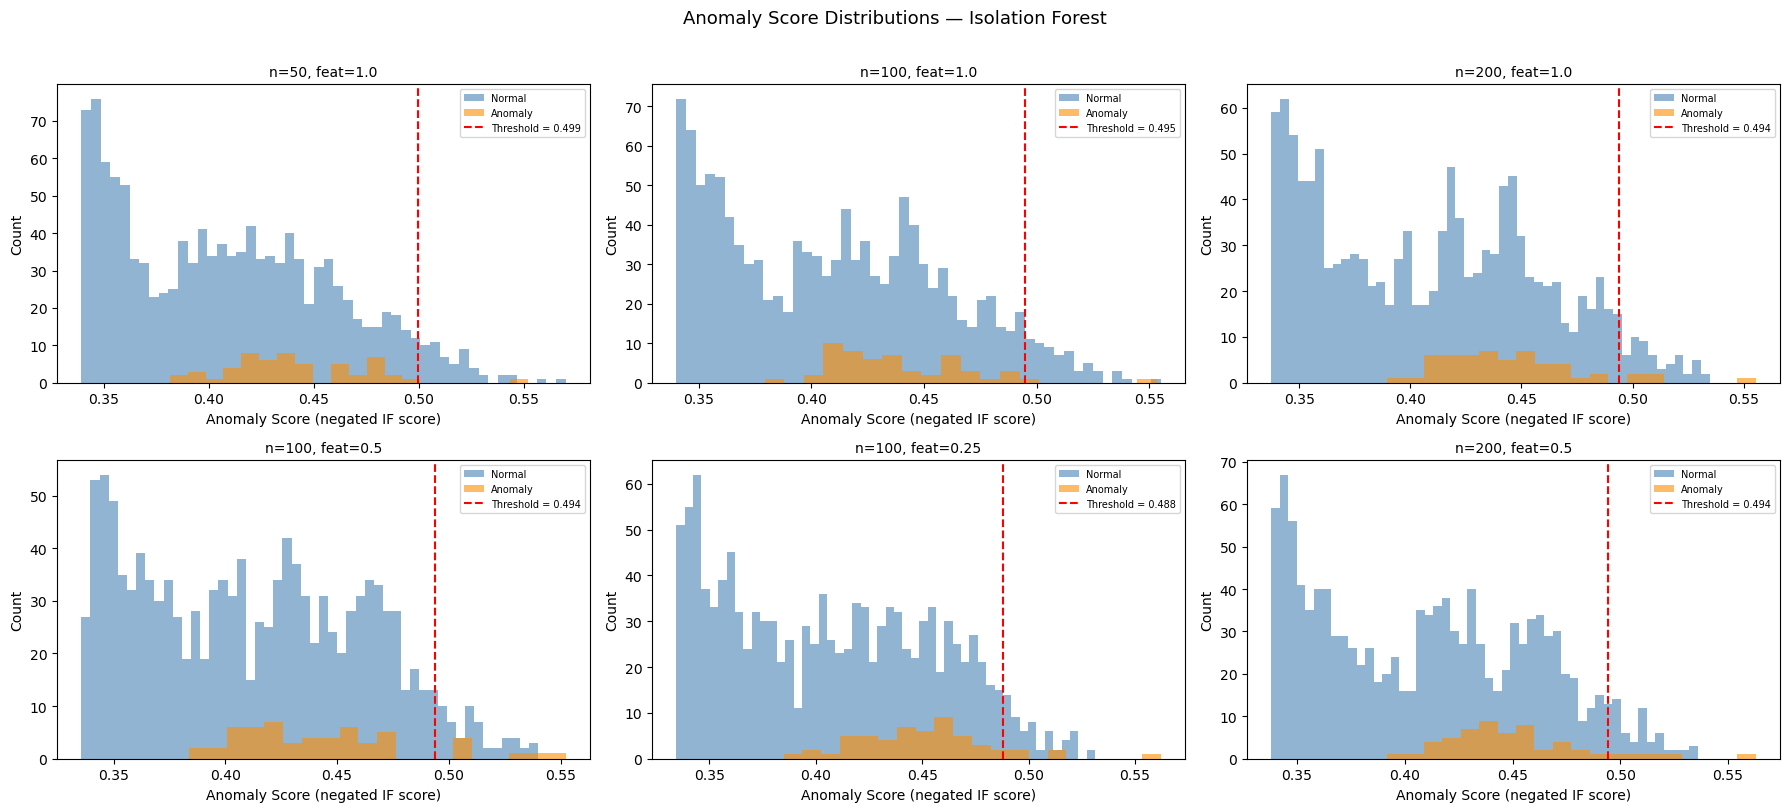

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]

    ax.hist(r['scores_normal'],  bins=50, alpha=0.6, color='steelblue',  label='Normal')
    ax.hist(r['scores_anomaly'], bins=20, alpha=0.6, color='darkorange', label='Anomaly')
    ax.axvline(r['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold = {r["threshold"]:.3f}')

    ax.set_title(r['label'], fontsize=10)
    ax.set_xlabel('Anomaly Score (negated IF score)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Anomaly Score Distributions — Isolation Forest', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/isolation_forest_anomaly_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

All 6 plots share a striking characteristic — the normal (blue) and anomaly (orange) distributions **completely overlap** across the 0.33–0.57 score range. Unlike KNN where normal scores peaked sharply at low values and anomaly scores spread higher, Isolation Forest produces nearly identical score ranges for both classes.

**n_estimators effect (top row):** The threshold barely changes across 50→100→200 trees (0.499→0.495→0.494). More trees slightly stabilize the scores but do not improve separation. The distributions look nearly identical across all three.

**max_features effect (bottom row):** Reducing features to 0.5 and 0.25 shifts the score range slightly and makes the distributions more spread out, but the overlap remains total. n=100, feat=0.25 shows the most spread, which is why it achieves the best AUC.

**Key problem:** Isolation Forest scores all samples — normal and anomaly alike — in a very narrow band (~0.33–0.57). There is no region where anomaly scores cluster distinctly above normal scores. Isolation Forest relies on samples being globally sparse to flag them as anomalies, but the ambient spectra are not sparse enough relative to the full 535-dimensional feature space.

## 6. Confusion Matrices

One confusion matrix per configuration, labeled with TN, FP, FN, TP.

**What to look for:** high TP (anomalies correctly caught) and low FN (anomalies missed). FN is the most costly error in anomaly detection.

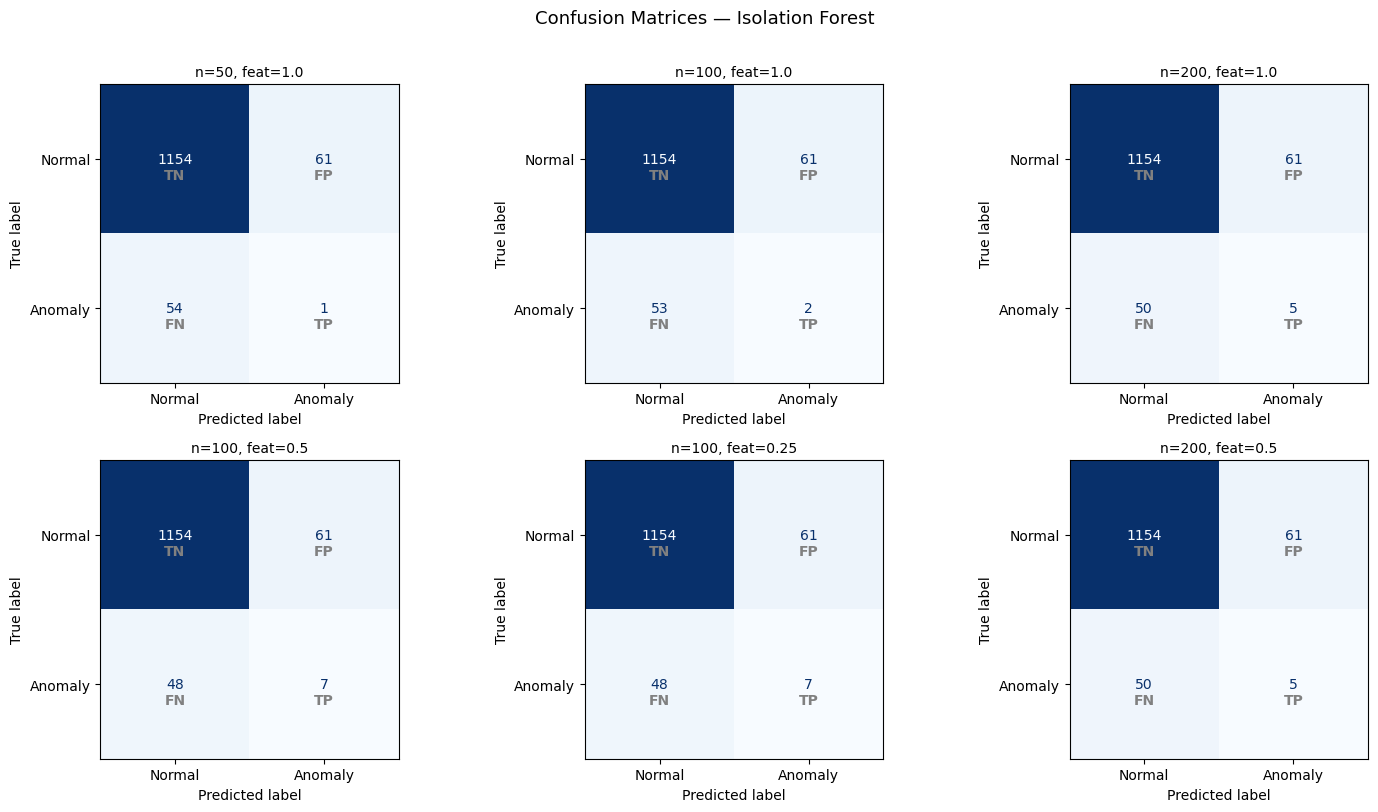

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for i, r in enumerate(results):
    ax = axes[i]

    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'\n\n{cell_labels[row][col]}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='gray')

    ax.set_title(r['label'], fontsize=10)

plt.suptitle('Confusion Matrices — Isolation Forest', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/isolation_forest_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

All 6 configurations show poor anomaly detection. FP=61 and TN=1154 are locked constant across all runs — the threshold behaviour on normal samples is identical regardless of configuration.

| Configuration | TP | FN | Recall |
|---|---|---|---|
| n=50, feat=1.0 | 1 | 54 | 0.018 |
| n=100, feat=1.0 | 2 | 53 | 0.036 |
| n=200, feat=1.0 | 5 | 50 | 0.091 |
| n=100, feat=0.5 | 7 | 48 | 0.127 |
| n=100, feat=0.25 | 7 | 48 | 0.127 |
| n=200, feat=0.5 | 5 | 50 | 0.091 |

The best result is only **TP=7**, which is far worse than the best KNN result of TP=25 (K=3, euclidean). Increasing `n_estimators` alone (50→100→200 at feat=1.0) gives marginal gains. Reducing `max_features` to 0.5 produces the most improvement, but gains plateau at feat=0.25 — further feature reduction provides no additional benefit.

## 7. ROC Curves

All 6 ROC curves on one chart for easy comparison. A curve closer to the top-left corner means better performance. The gray dashed diagonal is the random baseline (AUC = 0.5).

**What to look for:** the configuration with the highest AUC has the best threshold-independent separation ability.

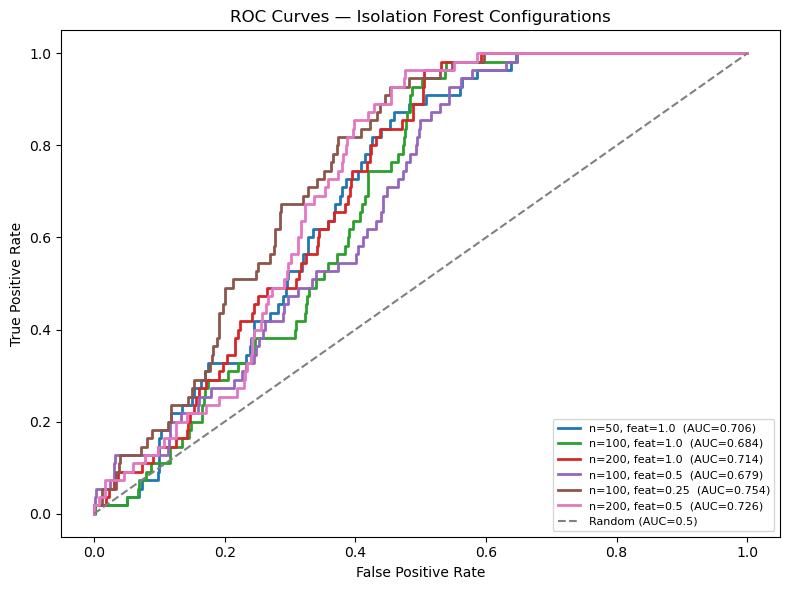

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, r in enumerate(results):
    ax.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
            label=f"{r['label']}  (AUC={r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC=0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Isolation Forest Configurations')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/isolation_forest_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

All curves sit above the random baseline but are noticeably weaker than the KNN results. AUC rankings:

| Rank | Configuration | AUC |
|------|--------------|-----|
| 1 | n=100, feat=0.25 | 0.754 |
| 2 | n=200, feat=0.5 | 0.726 |
| 3 | n=200, feat=1.0 | 0.714 |
| 4 | n=50, feat=1.0 | 0.706 |
| 5 | n=100, feat=1.0 | 0.684 |
| 6 | n=100, feat=0.5 | 0.679 |

The best AUC is only **0.754**, compared to KNN's best of **0.922**. Reducing `max_features` to 0.25 gives the best AUC — using fewer features forces the forest to find more diverse isolation paths, slightly improving separation. Increasing `n_estimators` alone does not consistently improve AUC. The curves are jagged and inconsistent, reflecting that Isolation Forest scores do not cleanly rank anomalies above normal samples for this dataset.

## 8. Summary Table

A single table summarising all key metrics across every configuration, sorted by AUC descending.

- **AUC** — threshold-independent ranking ability (higher is better)
- **TP** — anomalies correctly caught (higher is better)
- **FN** — anomalies missed (lower is better)
- **FP** — normal samples falsely flagged (lower is better)
- **Recall** — TP / (TP + FN), fraction of anomalies detected
- **Precision** — TP / (TP + FP), fraction of flagged samples that are real anomalies

In [8]:
summary = pd.DataFrame([{
    'Configuration': r['label'],
    'n_estimators':  r['n_estimators'],
    'max_features':  r['max_features'],
    'Threshold':     round(r['threshold'], 4),
    'AUC':           round(r['roc_auc'], 3),
    'TP':            int(r['tp']),
    'FN':            int(r['fn']),
    'FP':            int(r['fp']),
    'TN':            int(r['tn']),
    'Recall':        round(r['recall'], 3),
    'Precision':     round(r['precision'], 3),
} for r in results])

summary = summary.sort_values('AUC', ascending=False).reset_index(drop=True)
display(summary)

,Configuration,n_estimators,max_features,Threshold,AUC,TP,FN,FP,TN,Recall,Precision
0,"n=100, feat=0.25",100,0.25,0.4878,0.754,7,48,61,1154,0.127,0.103
1,"n=200, feat=0.5",200,0.50,0.4942,0.726,5,50,61,1154,0.091,0.076
2,"n=200, feat=1.0",200,1.00,0.4938,0.714,5,50,61,1154,0.091,0.076
3,"n=50, feat=1.0",50,1.00,0.4994,0.706,1,54,61,1154,0.018,0.016
4,"n=100, feat=1.0",100,1.00,0.4949,0.684,2,53,61,1154,0.036,0.032
5,"n=100, feat=0.5",100,0.50,0.4937,0.679,7,48,61,1154,0.127,0.103


**Results:**

**Best configuration: n=100, feat=0.25** with AUC=0.754 and TP=7.

**Overall conclusion — Isolation Forest significantly underperforms KNN on this dataset:**

| Metric | Best KNN (K=3, euclidean) | Best Isolation Forest (n=100, feat=0.25) |
|--------|--------------------------|------------------------------------------|
| AUC | 0.922 | 0.754 |
| TP | 25 | 7 |
| FN | 30 | 48 |
| Recall | 0.455 | 0.127 |

Isolation Forest struggles because the ambient and normal spectra occupy overlapping regions in the 535-dimensional feature space. Isolation Forest relies on anomalies being **globally sparse** — easy to isolate with random cuts. But the ambient spectra are not sparse enough in this high-dimensional space, so they receive similar isolation scores to normal samples. KNN's **local distance approach** is better suited to this dataset because it directly measures how unlike each sample is from its nearest normal neighbors, which is a more sensitive signal for detecting ambient particles.